## Race Position Predictability Modeling
The following section captures the lighter checkpoint-comparison idea that now feeds the milestone report's position section. The script-backed version of that simplified workflow lives in `scripts/build_position_comparison_analysis.py`, which generates the 2024 vs 2025 comparison curve consumed by the final notebook.


core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '11', '55', '16', '63', '4', '44', '81', '14', '18', '24', '20', '3', '22', '23', '27', '31', '10', '77', '2']
core           INFO 	Loading data for Saudi Arabian Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached dat

Saved predictability_curve.png
Lap 5 Accuracy: 90.32%
Lap 10 Accuracy: 91.36%
Lap 20 Accuracy: 96.63%
Lap 30 Accuracy: 98.85%
Lap 40 Accuracy: 100.00%
Lap 50 Accuracy: 100.00%


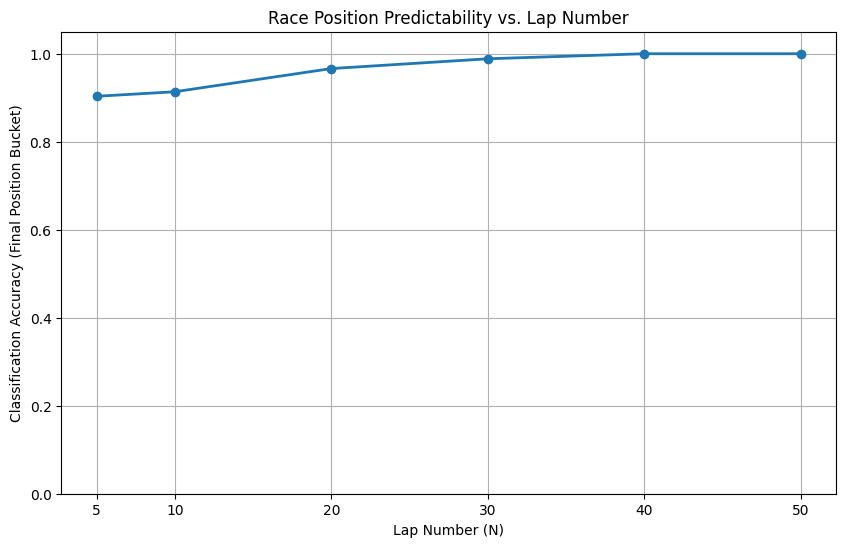

In [21]:
import pandas as pd
import numpy as np
import fastf1
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

os.makedirs('f1_cache', exist_ok=True)
fastf1.Cache.enable_cache('f1_cache')

races = ['Bahrain', 'Saudi Arabia', 'Australia', 'Japan', 'China']
year = 2024

lap_data = []
for race in races:
    try:
        session = fastf1.get_session(year, race, 'R')
        session.load(telemetry=False, weather=False)
        laps = session.laps
        laps['Race'] = race
        lap_data.append(laps)
    except Exception as e:
        print(f"Failed to load {race}: {e}")

if not lap_data:
    raise RuntimeError("No data loaded")

all_laps = pd.concat(lap_data, ignore_index=True)

# Filter out pit laps
clean_laps = all_laps[all_laps['PitInTime'].isnull() & all_laps['PitOutTime'].isnull()]

def assign_position_bucket(pos):
    if pd.isna(pos):
        return np.nan
    pos = int(pos)
    if pos <= 3: return '1_Podium (1-3)'
    elif pos <= 6: return '2_PointsHigh (4-6)'
    elif pos <= 10: return '3_PointsLow (7-10)'
    else: return '4_OutsidePoints (11+)'

final_positions = all_laps.groupby(['Race', 'Driver'])['Position'].last().reset_index()
final_positions.rename(columns={'Position': 'FinalPosition'}, inplace=True)

df = pd.merge(clean_laps, final_positions, on=['Race', 'Driver'], how='left')
df = df.dropna(subset=['Position', 'FinalPosition', 'TyreLife', 'Stint'])

df['Compound_Code'] = df['Compound'].astype('category').cat.codes
df['FinalBucket'] = df['FinalPosition'].apply(assign_position_bucket)

features = ['LapNumber', 'Position', 'TyreLife', 'Stint', 'Compound_Code']

X = df[features]
y = df['FinalBucket']

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X, y)

target_laps = [5, 10, 20, 30, 40, 50]
accuracies = []

for lap in target_laps:
    lap_df = df[df['LapNumber'] == lap]
    if len(lap_df) == 0:
        continue
    X_test = lap_df[features]
    y_test = lap_df['FinalBucket']
    
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    accuracies.append((lap, acc))

laps_eval, accs = zip(*accuracies)
plt.figure(figsize=(10, 6))
plt.plot(laps_eval, accs, marker='o', linestyle='-', linewidth=2)
plt.title('Race Position Predictability vs. Lap Number')
plt.xlabel('Lap Number (N)')
plt.ylabel('Classification Accuracy (Final Position Bucket)')
plt.ylim(0, 1.05)
plt.grid(True)
plt.xticks(target_laps)
plt.savefig('predictability_curve.png')
print("Saved predictability_curve.png")

for l, a in accuracies:
    print(f"Lap {l} Accuracy: {a:.2%}")


# Race Position Prediction: 2024 vs 2025 Analysis

## Objective
This section compares how well a simple race-state snapshot predicts a driver's final finishing bucket at several lap checkpoints in 2024 and 2025.

## What This Notebook Actually Does

### 1. Data Acquisition
For each target lap, the code loads race sessions from a fixed list of Grands Prix in 2024 and 2025 using **FastF1**.

### 2. Features Used at Lap $N$
For each driver present on that exact lap, the code keeps only:
- **Current Position**
- **Tyre Compound**
- **Tyre Life**

Although `Year`, `GrandPrix`, and `DriverNumber` are collected during extraction, they are not used as model features in the classifier.

### 3. Target Variable
The driver's final finishing position is converted into one of four buckets:
- **Podium**: P1-P3
- **Top Points**: P4-P6
- **Low Points**: P7-P10
- **Out of Points**: P11+

### 4. Modeling Approach
At each lap checkpoint, the code:
1. Builds one combined dataset for 2024 and one for 2025.
2. One-hot encodes tyre compound.
3. Trains a `RandomForestClassifier` with a random row-level `train_test_split`.
4. Records the resulting test accuracy for that season and lap.

The plot produced below is therefore a comparison of row-level holdout accuracy by lap checkpoint for this specific feature set and race subset.

---

### Data Pulling and Feature Extraction

In [23]:
import fastf1
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

fastf1.Cache.enable_cache('fastf1_cache')  # Cache is strictly necessary for processing multiple races

def extract_features_at_lap(year, grand_prix, target_lap):
    """
    Fetches the race session for a specific year and extracts the race state 
    for all drivers specifically at the target_lap.
    """
    try:
        session = fastf1.get_session(year, grand_prix, 'R')
        session.load(telemetry=False, weather=False, messages=False)
    except Exception as e:
        print(f"Failed to load {year} {grand_prix}: {e}")
        return None
        
    laps = session.laps
    if laps.empty:
        return None

    # Filter laps ending at the target
    current_state = laps[laps['LapNumber'] == target_lap].copy()
    if current_state.empty:
        return None
    
    # Target variable lookup: Final race position
    final_positions = []
    for driver in current_state['DriverNumber']:
        driver_laps = laps[laps['DriverNumber'] == driver]
        if not driver_laps.empty:
            final_pos = driver_laps.iloc[-1]['Position']
            final_positions.append(final_pos)
        else:
            final_positions.append(np.nan)
            
    current_state['FinalPosition'] = final_positions
    current_state['Year'] = year
    current_state['GrandPrix'] = grand_prix
    
    # Extract only the features we need
    features = current_state[['Year', 'GrandPrix', 'DriverNumber', 'Position', 'Compound', 'TyreLife', 'FinalPosition']]
    
    return features.dropna()

### Training the Classifier

In [25]:
def train_and_eval_for_lap(df_features):
    """
    Trains a Random Forest classifier to predict final position bucket and returns validation accuracy.
    """
    # Create target position buckets
    bins = [0, 3, 6, 10, 25]
    labels = ['Podium', 'Top Points', 'Low Points', 'Out of Points']
    df_features['PosBucket'] = pd.cut(df_features['FinalPosition'], bins=bins, labels=labels)
    
    # One-hot encode categorical features (like Tyre Compound)
    df_encoded = pd.get_dummies(df_features, columns=['Compound'], drop_first=True)
    
    # Establish X and y
    feature_cols = ['Position', 'TyreLife'] + [col for col in df_encoded.columns if 'Compound_' in col]
    X = df_encoded[feature_cols]
    y = df_encoded['PosBucket']
    
    if len(X) < 10:
        return np.nan # Not enough data
        
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(X_train, y_train)
    
    preds = rf.predict(X_test)
    return accuracy_score(y_test, preds)

### Predictability Curve (2024 vs 2025)

core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.8.1]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No ca

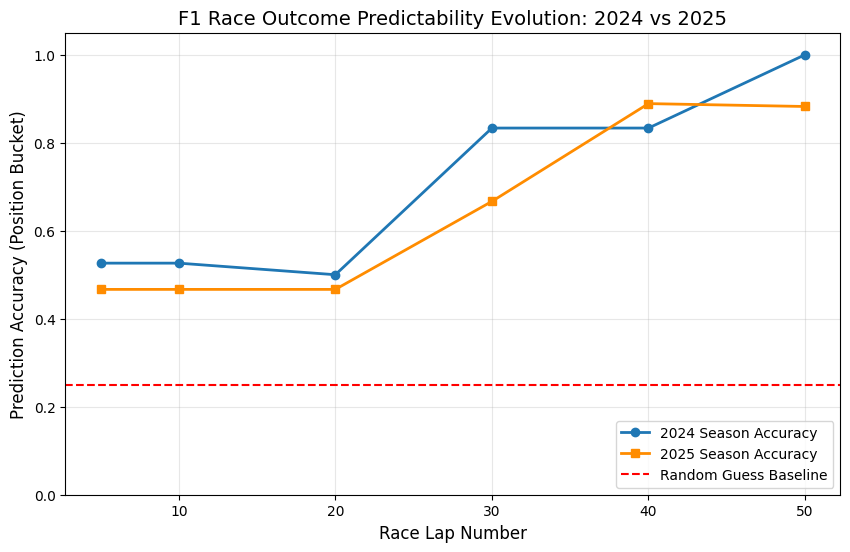

In [27]:
def run_comparison_analysis(races_list):
    """
    Iterates through specific lap checkpoints across a 2024 vs 2025 race set to map predictability growth.
    """
    lap_checkpoints = [5, 10, 20, 30, 40, 50]
    results_2024 = []
    results_2025 = []
    
    for lap in lap_checkpoints:
        # Build dataset for 2024 checkpoint
        races_24 = [extract_features_at_lap(2024, gp, lap) for gp in races_list]
        df_2024 = pd.concat([df for df in races_24 if df is not None], ignore_index=True) if races_24 else pd.DataFrame()
        
        # Build dataset for 2025 checkpoint
        races_25 = [extract_features_at_lap(2025, gp, lap) for gp in races_list]
        df_2025 = pd.concat([df for df in races_25 if df is not None], ignore_index=True) if races_25 else pd.DataFrame()
        
        # Evaluate predictability
        if not df_2024.empty:
            results_2024.append(train_and_eval_for_lap(df_2024))
        else:
            results_2024.append(np.nan)
            
        if not df_2025.empty:
            results_2025.append(train_and_eval_for_lap(df_2025))
        else:
            results_2025.append(np.nan)
            
    # Visualization: The Predictability Curve Comparison
    plt.figure(figsize=(10, 6))
    plt.plot(lap_checkpoints, results_2024, marker='o', linewidth=2, label='2024 Season Accuracy')
    plt.plot(lap_checkpoints, results_2025, marker='s', linewidth=2, label='2025 Season Accuracy', color='darkorange')
    
    plt.title('F1 Race Outcome Predictability Evolution: 2024 vs 2025', fontsize=14)
    plt.xlabel('Race Lap Number', fontsize=12)
    plt.ylabel('Prediction Accuracy (Position Bucket)', fontsize=12)
    plt.ylim(0, 1.05)
    plt.axhline(0.25, color='red', linestyle='--', label='Random Guess Baseline')
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)
    plt.show()

# --- Execution Entry Point ---
# Choose a subset of comparable early-to-mid season races
target_races = ['Bahrain', 'Saudi Arabia', 'Australia', 'Japan', 'Miami']
run_comparison_analysis(target_races)

## Notes on Interpretation
This notebook currently captures the exploratory framing behind the simplified comparison used in the final report. The canonical report-facing outputs for that lighter 2024 vs 2025 checkpoint comparison are now generated by `scripts/build_position_comparison_analysis.py`.
